In [2]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# from sklearn.metrics.pairwise import pairwise_distances
# from joblib import parallel_backend



# to fix - need to try scaling dataß

In [3]:
df = pd.read_csv('data-p4/grouped_delays_tod_and_weekend.csv')

In [4]:
df['dtap_scaled'] = (df['dtap'] - df['dtap'].min()) / (df['dtap'].max() - df['dtap'].min())
df['dtnn_scaled'] = (df['dtnn'] - df['dtnn'].min()) / (df['dtnn'].max() - df['dtnn'].min())


In [5]:
colors = ["#1b4a61", "#63afd3", "#41825d", "#1a3425"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors)

text = 10


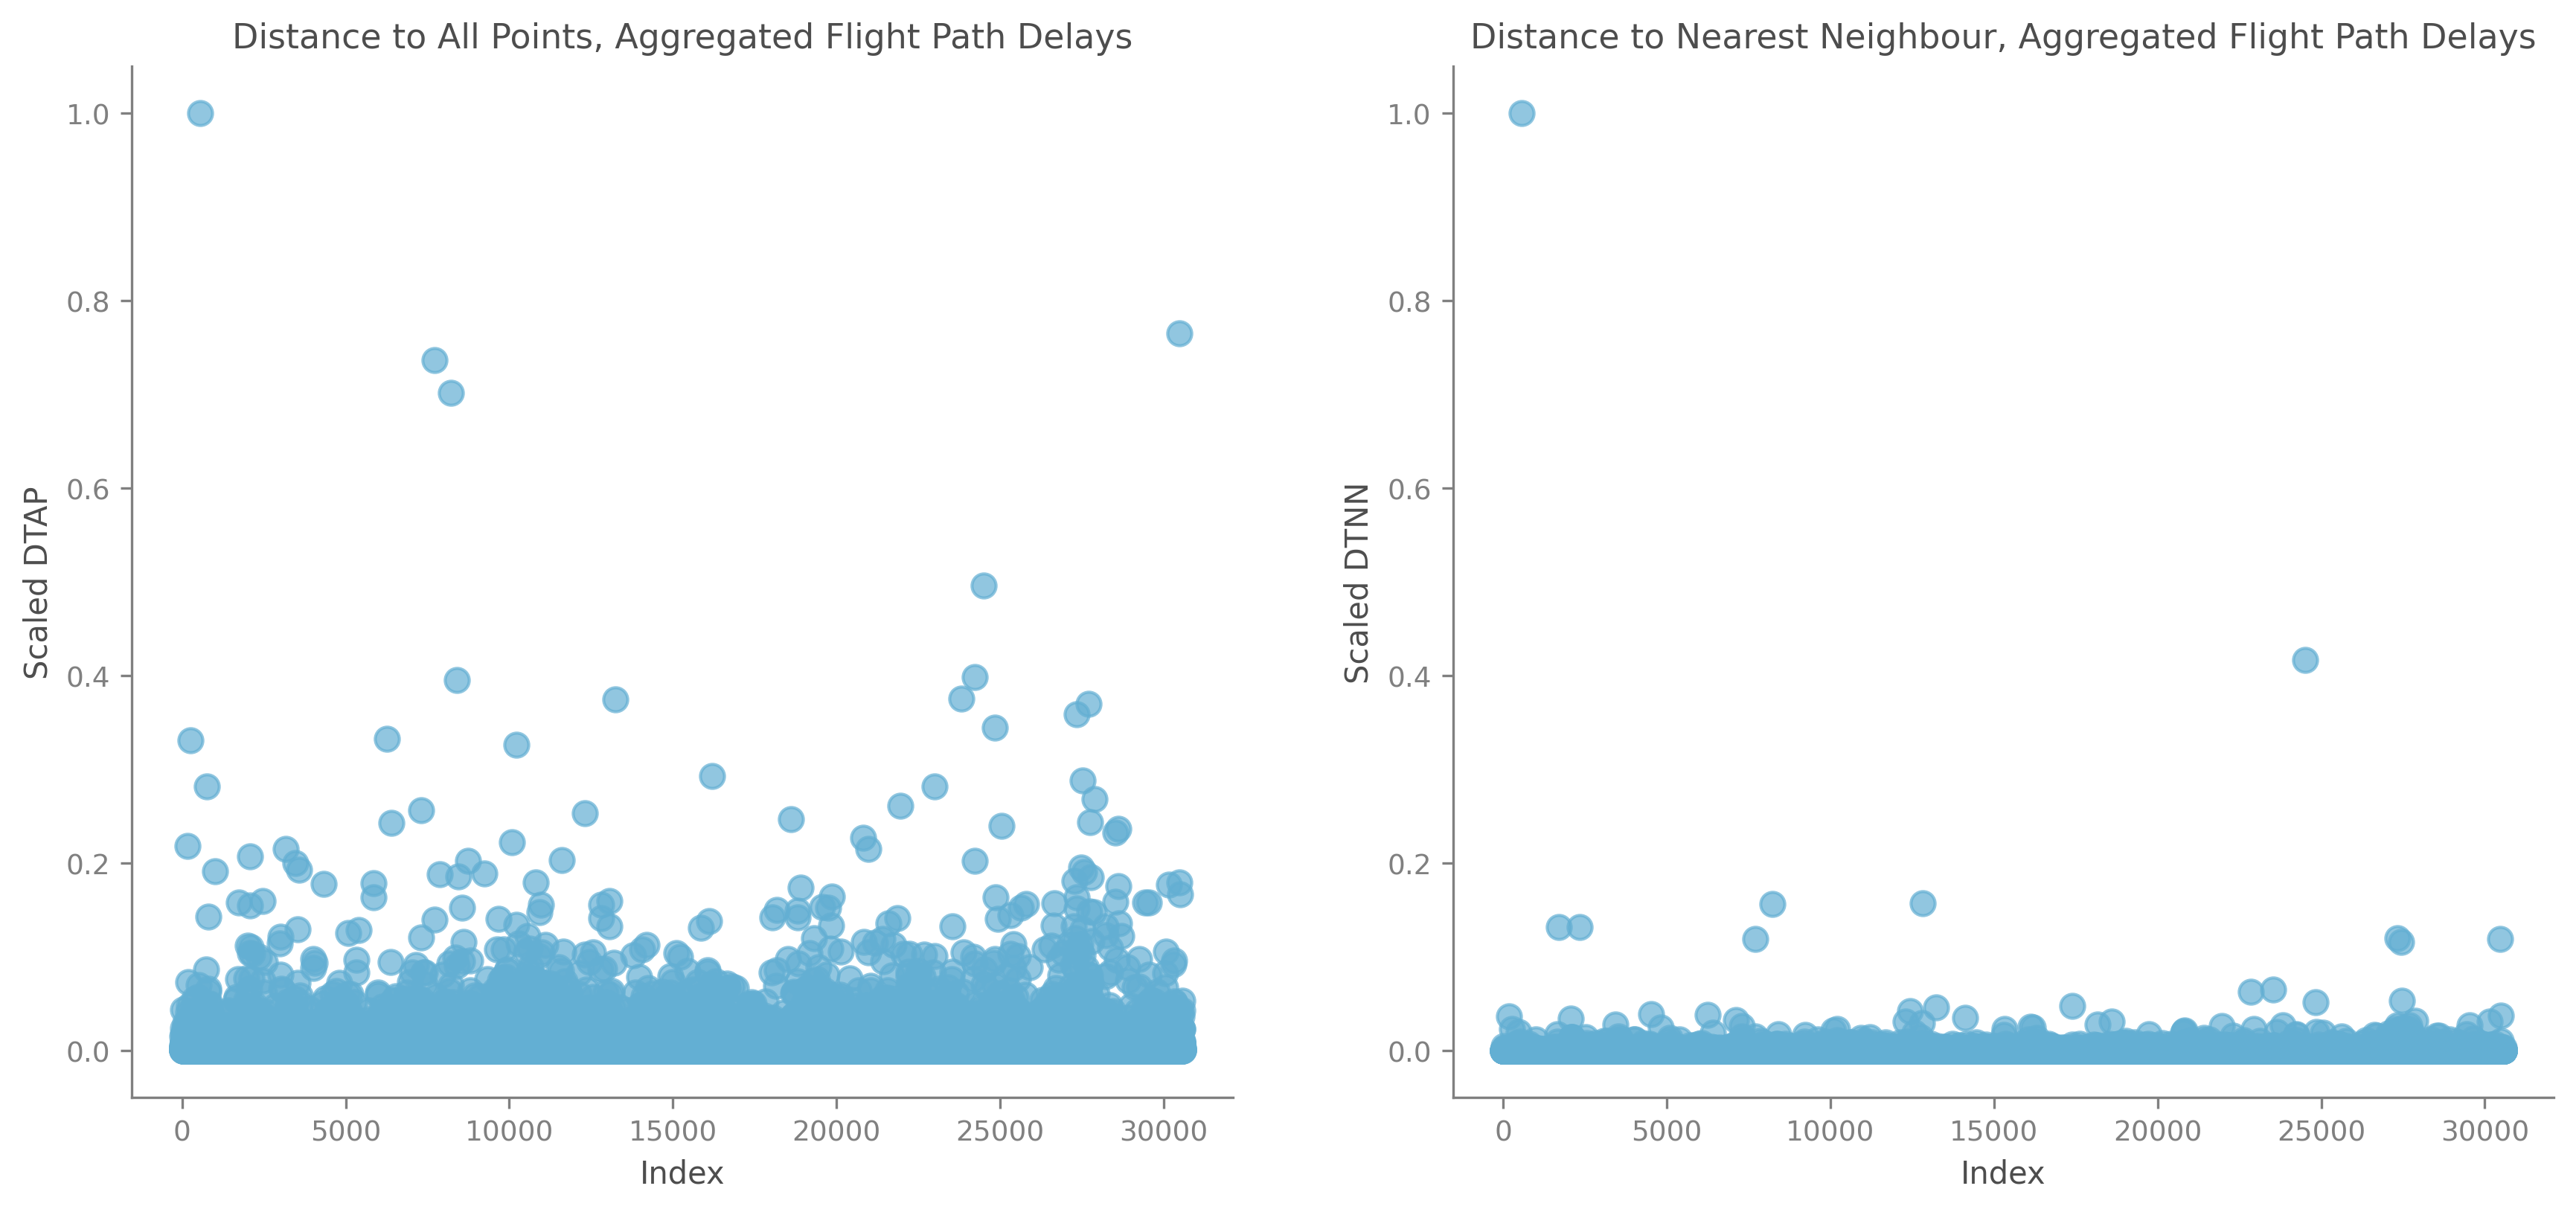

In [6]:
text=9
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=300)  # 1 row, 2 columns

# Plot 1: DTAP
axs[0].scatter(df.index, df['dtap_scaled'], color='#63afd3', alpha=0.7,s=60)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_color('gray')
axs[0].spines['bottom'].set_color('gray')
axs[0].tick_params(axis='both', which='both', colors='gray',labelsize=text)
axs[0].set_xlabel('Index', color='#4d4d4d',fontsize=text+1)
axs[0].set_ylabel('Scaled DTAP', color='#4d4d4d',fontsize=text+1)
axs[0].set_title('Distance to All Points, Aggregated Flight Path Delays', color='#4d4d4d', fontsize=text+2)

# Plot 2: DTNN
axs[1].scatter(df.index, df['dtnn_scaled'], color='#63afd3', alpha=0.7,s=60)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_color('gray')
axs[1].spines['bottom'].set_color('gray')
axs[1].tick_params(axis='both', which='both', colors='gray',labelsize=text)
axs[1].set_xlabel('Index', color='#4d4d4d',fontsize=text+1)
axs[1].set_ylabel('Scaled DTNN', color='#4d4d4d',fontsize=text+1)
axs[1].set_title('Distance to Nearest Neighbour, Aggregated Flight Path Delays', color='#4d4d4d', fontsize=text+2)

# Adjust layout
#plt.tight_layout()

# Show the figure
fig.savefig('figures-p4/dtap_dtnn_small.png', dpi=300, bbox_inches='tight')


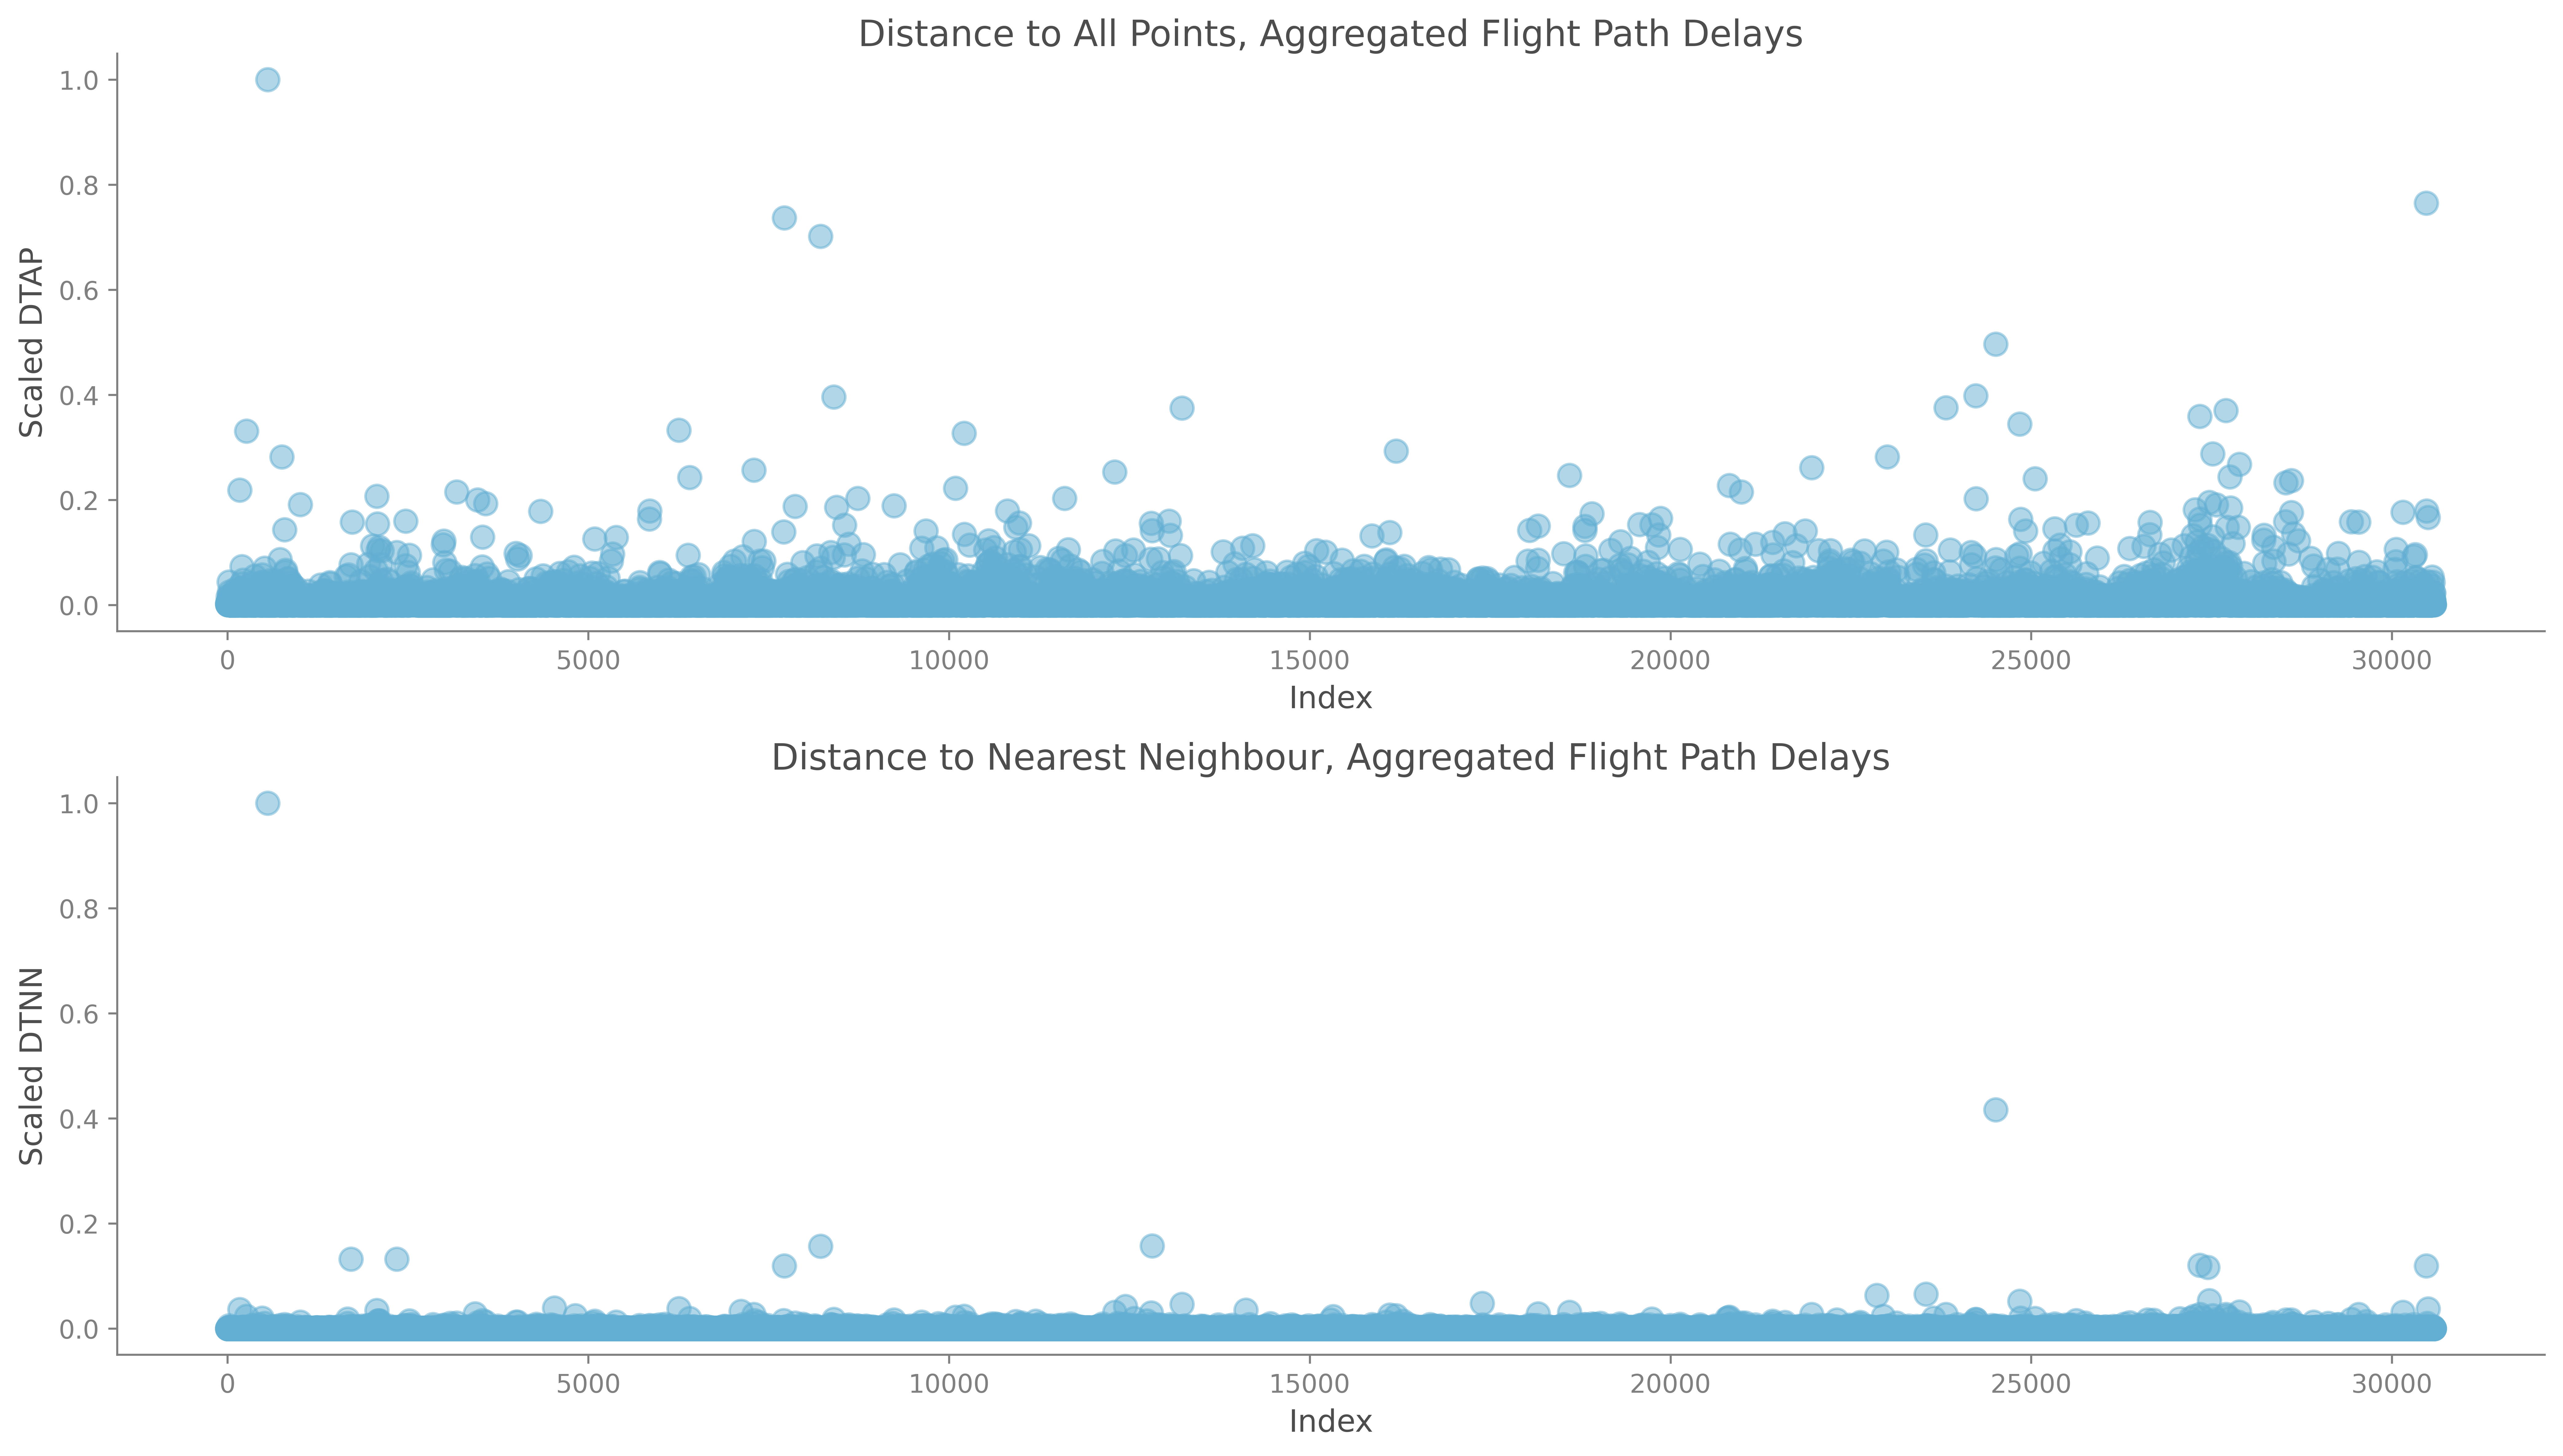

In [29]:
text=10
fig, axs = plt.subplots(2, 1, figsize=(14, 8), dpi=600)  # 1 row, 2 columns # old size was 14, 12

# Plot 1: DTAP
axs[0].scatter(df.index, df['dtap_scaled'], color='#63afd3', alpha=0.5,s=80) # s=80 to make dots bigger, old alpha was 0.5
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_color('gray')
axs[0].spines['bottom'].set_color('gray')
axs[0].tick_params(axis='both', which='both', colors='gray',labelsize=text)
axs[0].set_xlabel('Index', color='#4d4d4d',fontsize=text+2)
axs[0].set_ylabel('Scaled DTAP', color='#4d4d4d',fontsize=text+2)
axs[0].set_title('Distance to All Points, Aggregated Flight Path Delays', color='#4d4d4d', fontsize=text+4,pad=0)

# Plot 2: DTNN
axs[1].scatter(df.index, df['dtnn_scaled'], color='#63afd3', alpha=0.5,s=80) # s=80 to make dots bigger old alpha was 0.5
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_color('gray')
axs[1].spines['bottom'].set_color('gray')
axs[1].tick_params(axis='both', which='both', colors='gray',labelsize=text)
axs[1].set_xlabel('Index', color='#4d4d4d',fontsize=text+2)
axs[1].set_ylabel('Scaled DTNN', color='#4d4d4d',fontsize=text+2)
axs[1].set_title('Distance to Nearest Neighbour, Aggregated Flight Path Delays', color='#4d4d4d', fontsize=text+4,pad=0)

# Adjust layout
plt.tight_layout()

# Show the figure
fig.savefig('figures-p4/dtap_dtnn.png', dpi=600, bbox_inches='tight')


In [20]:
colors = ["#63afd3","#4D233A","#881838","#C40C36","#FF0134"]
cmap = LinearSegmentedColormap.from_list("my_custom_cmap", colors, N=256)

/var/folders/8t/19klq0xd5w7cf39d3893ts0w0000gn/T/ipykernel_49840/642783341.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.15, 1, 1])  # Adjust the layout to accommodate the color bar


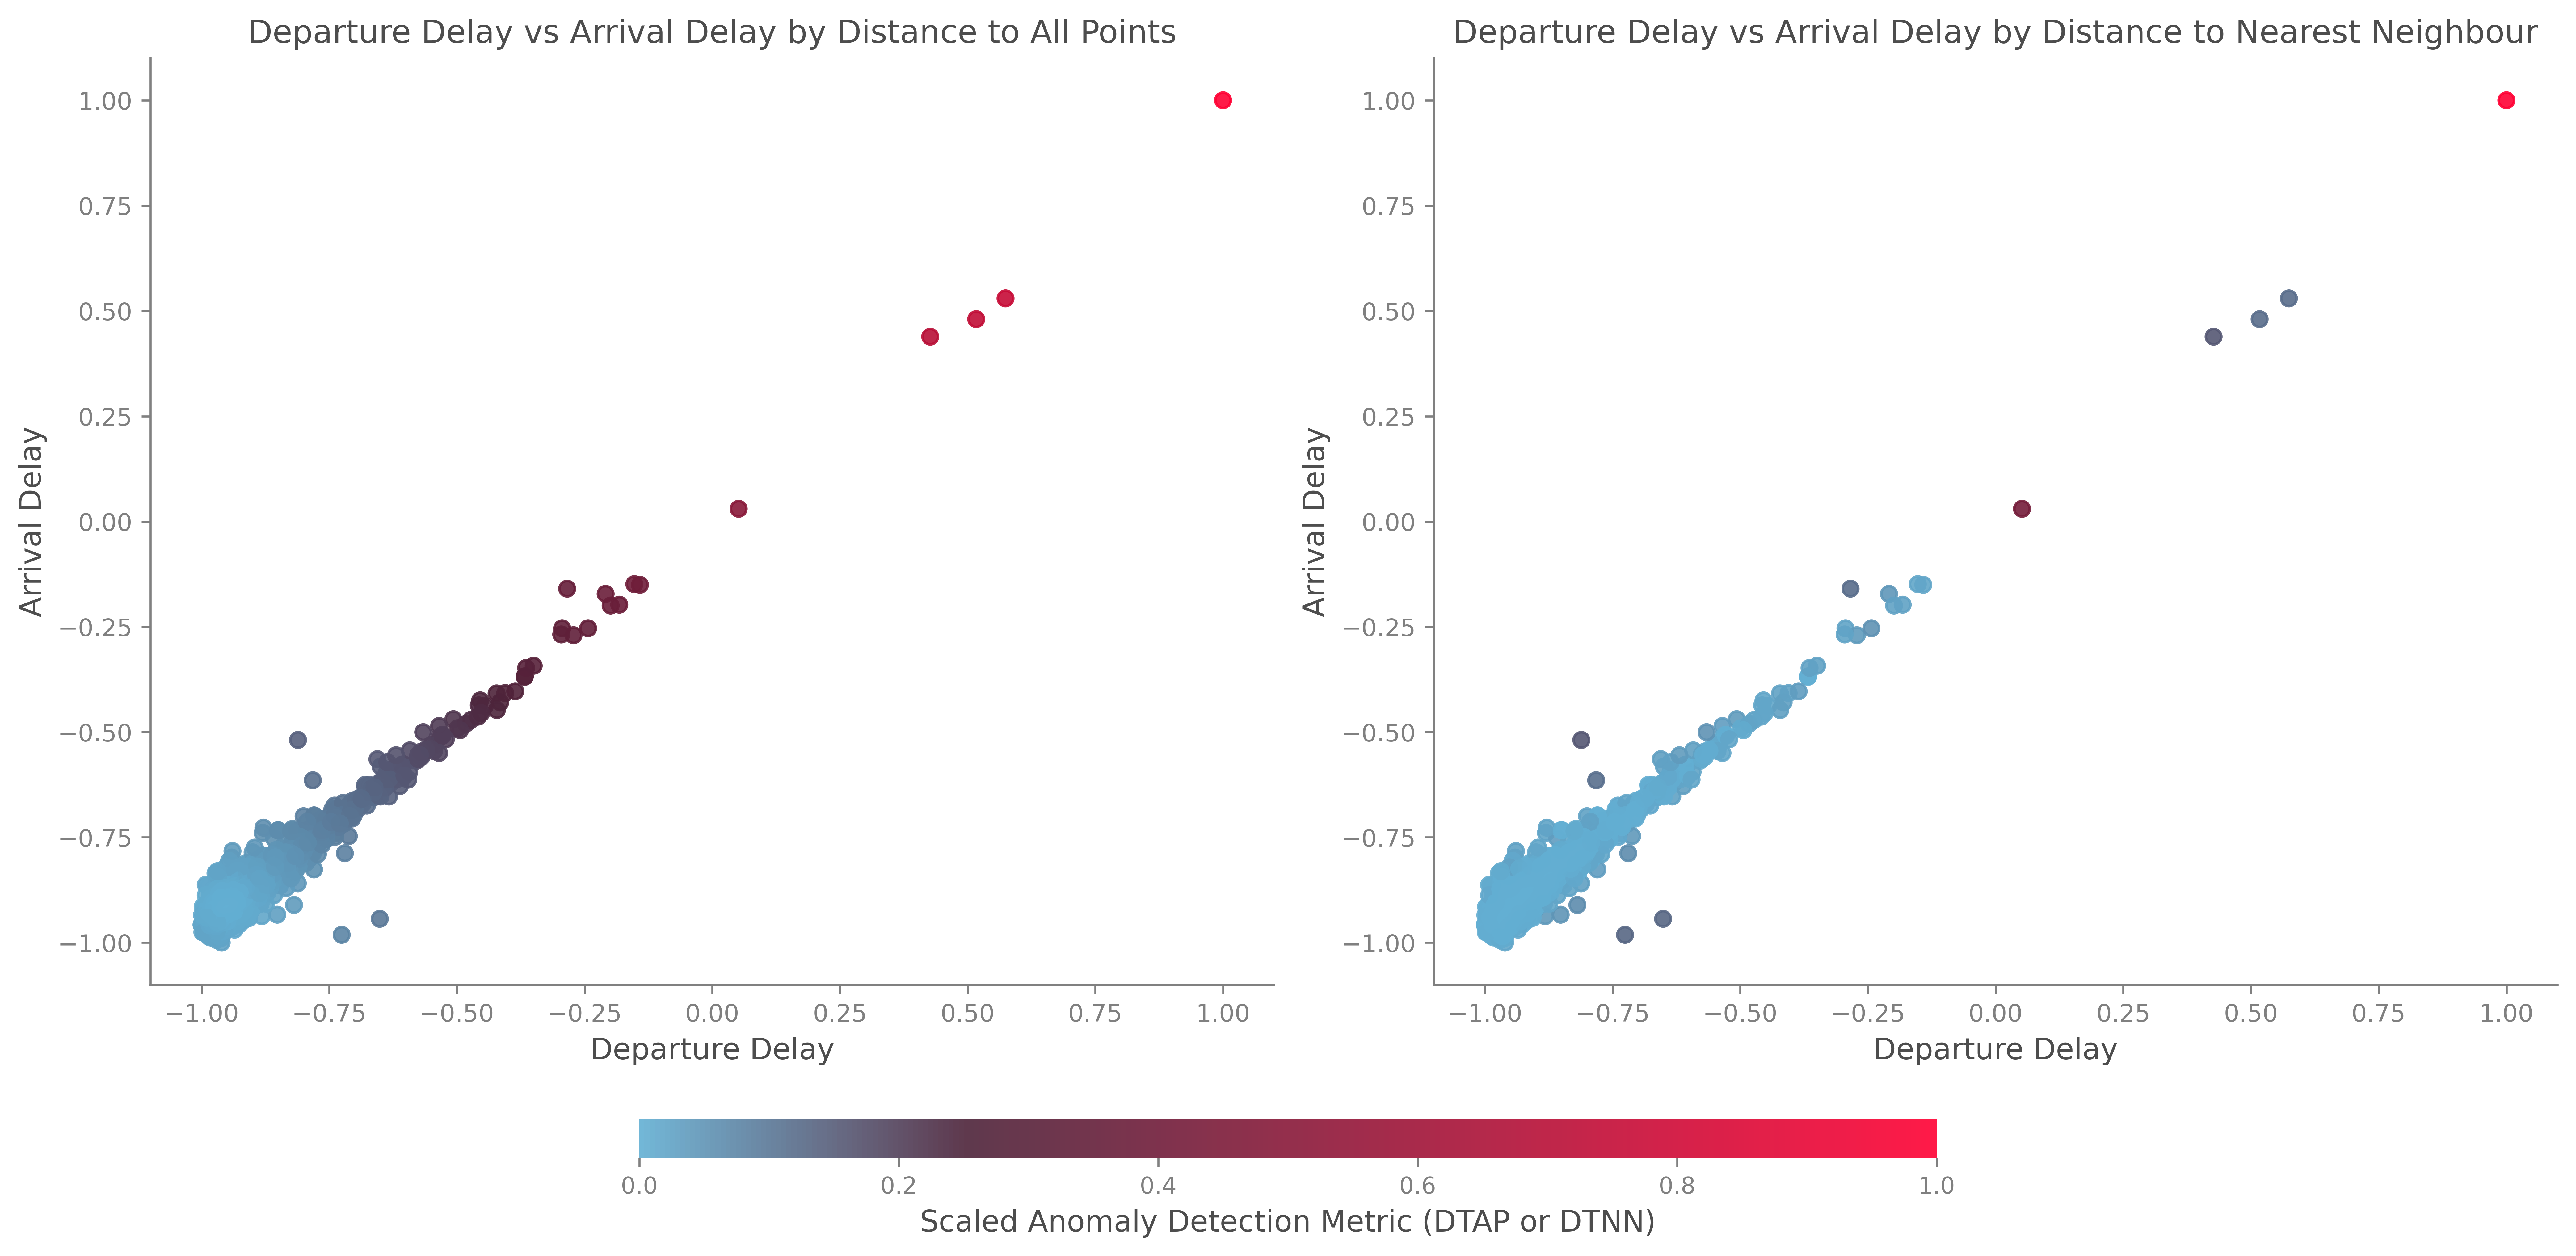

In [30]:

import matplotlib.gridspec as gridspec

text=9.5

# Create a figure and two subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 7), dpi=600)  # 1 row, 2 columns

# Plot 1: DTAP
scatter1 = axs[0].scatter(
    x=df['DEP_DELAY_scaled'], 
    y=df['ARR_DELAY_scaled'], 
    c=df['dtap_scaled'],  # Continuous variable for color
    cmap=cmap,  # Colormap
    alpha=0.9
)

# Customize axes for Plot 1
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_color('gray')
axs[0].spines['bottom'].set_color('gray')
axs[0].tick_params(axis='both', which='both', colors='gray', labelsize=text)
axs[0].set_xlabel('Departure Delay', color='#4d4d4d', fontsize=text+2)
axs[0].set_ylabel('Arrival Delay', color='#4d4d4d', fontsize=text+2)
axs[0].set_title('Departure Delay vs Arrival Delay by Distance to All Points', color='#4d4d4d', fontsize=text+3)

# Plot 2: DTNN
scatter2 = axs[1].scatter(
    x=df['DEP_DELAY_scaled'], 
    y=df['ARR_DELAY_scaled'], 
    c=df['dtnn_scaled'],  # Continuous variable for color
    cmap=cmap,  # Colormap
    alpha=0.9
)

# Customize axes for Plot 2
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_color('gray')
axs[1].spines['bottom'].set_color('gray')
axs[1].tick_params(axis='both', which='both', colors='gray', labelsize=text)
axs[1].set_xlabel('Departure Delay', color='#4d4d4d', fontsize=text+2)
axs[1].set_ylabel('Arrival Delay', color='#4d4d4d', fontsize=text+2)
axs[1].set_title('Departure Delay vs Arrival Delay by Distance to Nearest Neighbour', color='#4d4d4d', fontsize=text+3)

# Add a color bar below both plots
cbar_ax = fig.add_axes([0.25, 0.1, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter2, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_visible(False)
cbar.ax.tick_params(colors='gray', labelsize=9)
cbar.set_label("Scaled Anomaly Detection Metric (DTAP or DTNN)", color='#4d4d4d', fontsize=text+2)

# Adjust layout
plt.tight_layout(rect=[0, 0.15, 1, 1])  # Adjust the layout to accommodate the color bar

# Show the figure
#plt.show()
fig.savefig('figures-p4/new_dtap_dtnn_colour_plot.png', dpi=600, bbox_inches='tight')


In [ ]:
dtap_top10 = df['dtap'].nlargest(10).index.to_list()
df.loc[dtap_top10]

,DEST_AIRPORT_ID,ORIGIN_AIRPORT_ID,Cluster,ARR_DELAY,DEP_DELAY,ARR_DELAY_scaled,DEP_DELAY_scaled,dtap
584,10397,10257,Weekday 16:00 - 20:00,1241.000000,1197.000000,1.000000,1.000000,83291.669545
31458,15624,10676,Weekend 16:00 - 20:00,936.000000,937.000000,0.529684,0.574120,63929.877941
7938,11292,11540,Weekday 16:00 - 20:00,904.000000,902.000000,0.480339,0.516790,61619.138553
8451,11292,14771,Weekday 0:00 - 4:00,877.000000,847.000000,0.438705,0.426699,58752.513342
25289,14122,14771,Weekday 4:00 - 8:00,612.000000,618.000000,0.030069,0.051597,41822.693394
25011,14112,13367,Weekend 12:00 - 16:00,495.000000,500.000000,-0.150347,-0.141687,33738.157238
8646,11298,10685,Weekday 8:00 - 12:00,496.000000,493.333333,-0.148805,-0.152607,33528.550067
24589,14107,13264,Weekday 12:00 - 16:00,464.333333,475.333333,-0.197636,-0.182091,31848.355559
13667,12264,14747,Weekday 12:00 - 16:00,481.000000,459.000000,-0.171935,-0.208845,31804.929032
28597,14771,14698,Weekday 4:00 - 8:00,463.000000,465.000000,-0.199692,-0.199017,31428.197259


In [ ]:
dtnn_top10 = df['dtnn'].nlargest(10).index.to_list()
df.loc[dtnn_top10]

,DEST_AIRPORT_ID,ORIGIN_AIRPORT_ID,Cluster,ARR_DELAY,DEP_DELAY,ARR_DELAY_scaled,DEP_DELAY_scaled,dtap,dtnn
584,10397,10257,Weekday 16:00 - 20:00,1241.000000,1197.00,1.000000,1.000000,83291.669545,0.634485
25289,14122,14771,Weekday 4:00 - 8:00,612.000000,618.00,0.030069,0.051597,41822.693394,0.264403
13202,12197,13204,Weekend 16:00 - 20:00,256.000000,91.25,-0.518890,-0.811220,12612.628367,0.099928
8451,11292,14771,Weekday 0:00 - 4:00,877.000000,847.00,0.438705,0.426699,58752.513342,0.099245
1747,10423,10721,Weekday 16:00 - 20:00,-44.000000,143.50,-0.981496,-0.725635,7243.749757,0.083674
2397,10577,11433,Weekday 16:00 - 20:00,-19.333333,189.00,-0.943459,-0.651106,9174.590932,0.083674
28210,14771,10849,Weekday 12:00 - 16:00,489.000000,413.00,-0.159599,-0.284193,30501.844627,0.076351
7938,11292,11540,Weekday 16:00 - 20:00,904.000000,902.00,0.480339,0.516790,61619.138553,0.075641
31458,15624,10676,Weekend 16:00 - 20:00,936.000000,937.00,0.529684,0.574120,63929.877941,0.075641
28330,14771,12264,Weekday 16:00 - 20:00,194.000000,109.00,-0.614495,-0.782146,10297.320615,0.073691


In [29]:
set(dtap_top10).intersection(set(dtnn_top10))

{584, 7938, 8451, 25289, 31458}

Here, we will treat the deaprture delay as the x-coordinate, the arrival delay as the y-coordinate, and compare the euclidean distances of all of these 